---
title: Capa convolucional
subject: Aprendizaje Profundo
subtitle: 
short_title: Capa convolucional
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorgeanais/libro_aprendizaje_profundo/blob/main/cap2/020_capaconv.ipynb)

**Objetivo**: En este notebook, visualizamos el efecto de aplicar un filtro convolucional a una imagen, y el rol de este en una capa convolucional.

---

## ¿Qué es la convolución?

Una **convolución** es una operación matemática que combina dos funciones para producir una tercera. En el procesamiento de imágenes, se aplica un pequeño arreglo de números llamado **kernel** o **filtro** sobre cada región de la imagen para producir una nueva imagen transformada.
}

### ¿Cómo funciona en la práctica?

El filtro se desliza  sobre toda la imagen, y en cada posición se calcula el **producto punto** entre los valores del filtro y los píxeles que cubre. El resultado es un único número que resume la presencia de un patrón en esa región.

**Intuición**: un filtro detecta la presencia de patrones específicos (bordes, texturas, esquinas) en distintas regiones de la imagen.


---
## 1. Carga y Preprocesamiento de la Imagen

Antes de aplicar cualquier filtro, debemos:
1. **Cargar** la imagen en color (RGB)
2. **Convertir a escala de grises**
3. **Normalizar** los valores al rango $[0, 1]$ dividiendo por 255 — esto mejora la estabilidad numérica del modelo


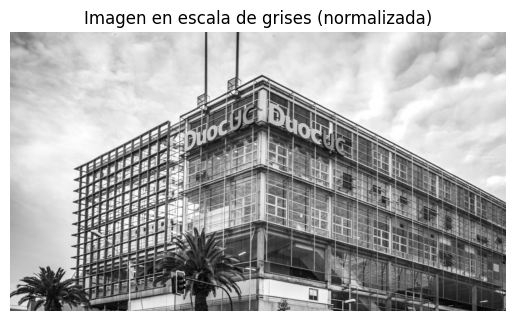

In [ ]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

# TODO: Puedes cambiar la ruta para usar tu propia imagen.
img_path = '/content/plaza-vespucio.jpg'

# Cargar imagen en color (OpenCV usa formato BGR, no RGB)
bgr_img = cv2.imread(img_path)

# Convertir a escala de grises (un solo canal de intensidad)
gray_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)

# Normalizar: reescalar valores al rango [0, 1]
gray_img = gray_img.astype("float32") / 255

# Visualizar imagen resultante
plt.imshow(gray_img, cmap='gray')
plt.title('Imagen en escala de grises (normalizada)')
plt.axis('off')
plt.show()


---
## 2. Definición de los Filtros

### El filtro de Sobel

El filtro base que utilizaremos es el **filtro de Sobel horizontal**, un operador clásico para detectar bordes verticales:

$$K_{Sobel-X} = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$

Este filtro responde fuertemente ante **cambios bruscos de intensidad en dirección horizontal** (es decir, detecta bordes verticales).

A partir de él, construiremos 4 filtros derivados:

| Filtro | Operación | Qué detecta |
|---|---|---|
| Filtro 1 | $K$ | Bordes verticales (izq → der) |
| Filtro 2 | $-K$ | Bordes verticales (der → izq) |
| Filtro 3 | $K^T$ | Bordes horizontales (arriba → abajo) |
| Filtro 4 | $-K^T$ | Bordes horizontales (abajo → arriba) |


In [ ]:
import numpy as np

# Filtro de Sobel horizontal: detecta bordes verticales.
# Se puede modificar libremente para experimentar con otros filtros.
filter_vals = np.array(
    [
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1],
    ]
)

print('Forma del filtro (filas x columnas):', filter_vals.shape)


Forma del filtro (filas x columnas): (3, 3)


In [ ]:
# Construimos 4 filtros a partir del filtro base.
filter_1 = filter_vals
filter_2 = -filter_1
filter_3 = filter_1.T
filter_4 = -filter_3

filters = np.array([filter_1, filter_2, filter_3, filter_4])

print('Filtro 1 (Sobel horizontal):\n', filter_1)


Filtro 1 (Sobel horizontal):
 [[-1  0  1]
 [-2  0  2]
 [-1  0  1]]


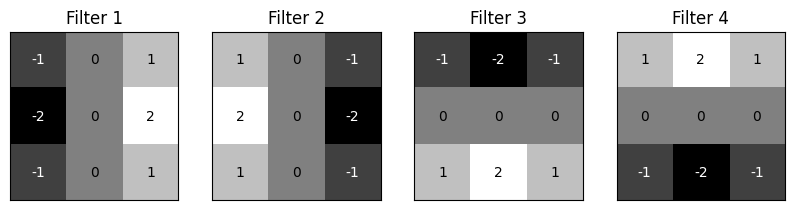

In [ ]:
# Veamos todos los filtros.
fig = plt.figure(figsize=(10, 5))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1, xticks=[], yticks=[])
    ax.imshow(filters[i], cmap='gray')
    ax.set_title('Filter %s' % str(i+1))
    width, height = filters[i].shape
    for x in range(width):
        for y in range(height):
            ax.annotate(str(filters[i][x][y]), xy=(y,x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if filters[i][x][y]<0 else 'black')

---
## 3. Definición de la Capa Convolucional en PyTorch

Vamos a construir una pequeña red neuronal con **una sola capa convolucional** usando PyTorch.

Importante: ¡No entrenaremos la red! solo asignamos manualmente los filtros definidos arriba como pesos, lo que nos permite visualizar exactamente qué hace cada filtro.


In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms


In [ ]:
from torch import nn, optim
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, weight):
        super().__init__()

        # Extraemos alto y ancho del kernel desde la forma del tensor de pesos.
        # El tensor weight tiene forma (out_channels, in_channels, k_height, k_width)
        k_height, k_width = weight.shape[2:]

        # Capa convolucional:
        # - 1 canal de entrada (imagen en escala de grises)
        # - 4 canales (uno por cada filtro)
        # - sin bias para mantener el efecto puro del filtro
        self.conv = nn.Conv2d(1, 4, kernel_size=(k_height, k_width), bias=False)

        # Asignamos los pesos manualmente (sin entrenamiento)
        self.conv.weight = torch.nn.Parameter(weight)

    def forward(self, x):
        # Paso 1: aplicar la convolución → obtenemos el feature map crudo
        conv_x = self.conv(x)

        # Paso 2: aplicar la función de activación ReLU
        # ReLU(z) = max(0, z) → elimina valores negativos (los deja en 0)
        activated_x = F.relu(conv_x)

        # Retornamos ambas salidas para poder visualizarlas
        return conv_x, activated_x


### Preparación del tensor de pesos


In [ ]:
# Convertimos el arreglo numpy a tensor PyTorch y ajustamos la forma.
# unsqueeze(1) agrega la dimensión de 'in_channels' en la posición 1:
#   (4, 3, 3)  →  (4, 1, 3, 3)  [out_channels, in_channels, height, width]
weight = torch.from_numpy(filters).unsqueeze(1).type(torch.FloatTensor)
print('Forma del tensor de pesos:', weight.shape)


Forma del tensor de pesos: torch.Size([4, 1, 3, 3])


In [ ]:
# Instanciamos el modelo con los pesos predefinidos
model = Net(weight)
print(model)


Net(
  (conv): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), bias=False)
)


---
## 4. Visualización de la Salida

Esta función recibe la salida de una capa convolucional y grafica cada uno de los **feature maps** generados.



In [ ]:
# Defina la función viz_layer
def viz_layer(layer, n_filters= 4):
    fig = plt.figure(figsize=(20, 20))

    for i in range(n_filters):
        ax = fig.add_subplot(1, n_filters, i+1, xticks=[], yticks=[])
        ax.imshow(np.squeeze(layer[0,i].data.numpy()), cmap='gray')
        ax.set_title('Salida %s' % str(i+1))



### Resultado sin y con ReLU

Compararemos las salidas:
- **Sin ReLU (`conv_layer`)**: los feature maps pueden tener valores negativos (representan bordes en dirección opuesta)
- **Con ReLU (`activated_layer`)**: los valores negativos se eliminan; solo se preservan las activaciones positivas


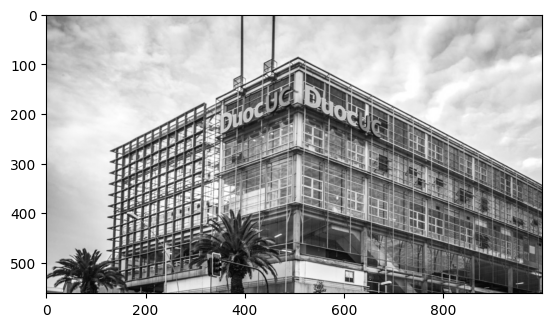

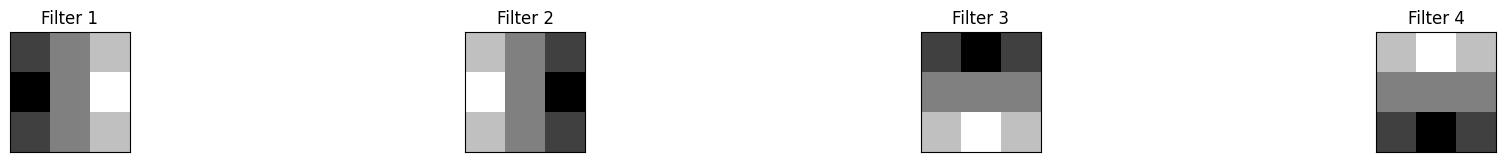

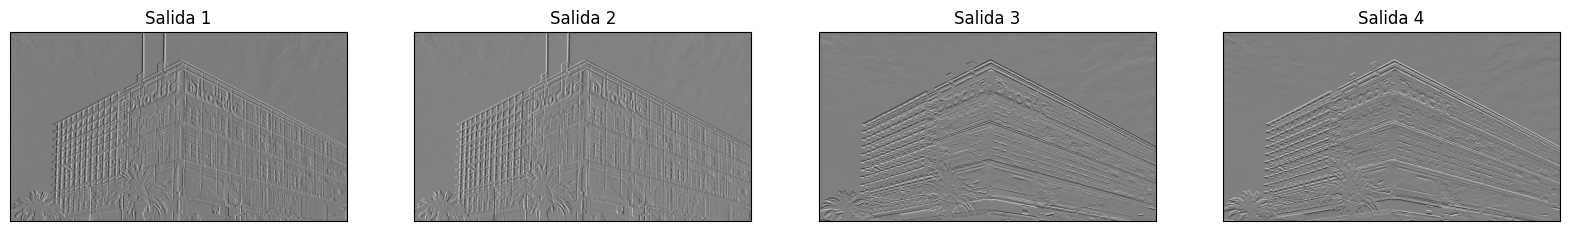

In [ ]:
# Imagen original.
plt.imshow(gray_img, cmap='gray')

# Visualizando los filtros.
fig = plt.figure(figsize=(12, 6))
fig.subplots_adjust(left=0, right=1.5, bottom=0.8, top=1, hspace=0.05, wspace=0.05)
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1, xticks=[], yticks=[])
    ax.imshow(filters[i], cmap='gray')
    ax.set_title('Filter %s' % str(i+1))


# Convirtiendo a un tensor la imagen para ser procesada por la red.
gray_img_tensor = torch.from_numpy(gray_img).unsqueeze(0).unsqueeze(1)

# Obtengamos las capas.
conv_layer, activated_layer = model(gray_img_tensor)

# Veamos la salida. SIn aplicar relu
viz_layer(conv_layer)

### Efecto de la función de activación ReLU

La función ReLU (*Rectified Linear Unit*) convierte todos los valores negativos en cero.

> 💡 Observa cómo después de ReLU los feature maps solo retienen las regiones donde el filtro encontró el patrón con mayor intensidad.


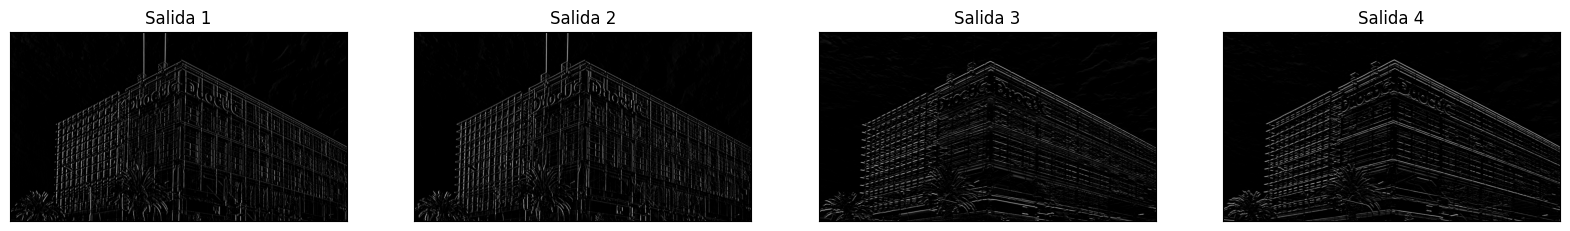

In [ ]:
# Aplicando Relu
viz_layer(activated_layer)

### <font color="blue">**Ejercicio 1.**  Preguntas de reflexión</font>

<font color="green">1. ¿Qué diferencias observas en los feature maps según el filtro utilizado?</font>
<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
Dependiendo del filtro se obtienen resultados diferentes. Por ejemplo, los filtros de deteccioń de bordes (Sobel, Laplacian) muestran alta activación solo en las zonas de transición brusca de intensidad. Por otro lado, el filtro de suavizado (Blur) es muy similar a la imagen original, pero con menos detalle.
</p>
</details>

---

<font color="green">2. ¿Por qué crees que las redes convolucionales profundas aprenden sus propios filtros en lugar de usar filtros predefinidos como Sobel?</font>
<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
Las CNN profundas aprenden sus propios filtros. Una red entrenada para reconocer rostros aprenderá filtros específicos para esa tarea.
Además, la información útil cambia según la profundidad: las primeras capas aprenden patrones simples (bordes, texturas), pero las capas profundas aprenden conceptos de alto nivel. Finalmente, al aprender por backpropagation, todos los filtros se optimizan en conjunto para minimizar el error final.

Curiosamente, los filtros aprendidos en las primeras capas de redes como AlexNet se parecen espontáneamente a detectores de Sobel o Gabor — la red los redescubre sola. En capas más profundas, en cambio, los filtros no tienen equivalente manual conocido.
</p>
</details>

---
## <font color="blue">**Ejercicio 2.** Experimenta</font>

Repite la operación de convolución modificando el filtro (puedes probar alguno de los siguientes) y cambiando la imágen por otra.

**Filtros sugeridos:**

| Nombre | Kernel | Efecto |
|---|---|---|
| Blur (suavizado) | `[[1,1,1],[1,1,1],[1,1,1]] / 9` | Suaviza la imagen |
| Sharpen (nitidez) | `[[0,-1,0],[-1,5,-1],[0,-1,0]]` | Resalta detalles |
| Emboss (relieve) | `[[-2,-1,0],[-1,1,1],[0,1,2]]` | Efecto relieve |
| Laplacian (bordes) | `[[0,1,0],[1,-4,1],[0,1,0]]` | Detecta todos los bordes |

